Import Dependencies

In [15]:
from pydantic import BaseModel

from langsmith import traceable, get_current_run_tree

import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import SystemMessage
from IPython.display import Image, display

from typing import Literal, Dict, Any, Annotated, List
from pydantic import Field
from operator import add

import random
import openai
import pandas as pd

from jinja2 import Template

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery


Query Expansion (Parallel Execution)

In [16]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    question_relevant: bool = False
    query: str = ""
    k: int = 10

Query Expansion / Rewriting Node

In [17]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [18]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

In [19]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages

Retriever Node

In [20]:
@traceable(    
name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    hybrid = True

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=state["query"],
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=state["k"]
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }


Aggregator Node

In [29]:
class AggregatorResponse(BaseModel):
    answer: str

In [21]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

User Intent Router Node

In [22]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if the users question is not relevant to the products.")

In [23]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

## Instructions

- Determine whether the question is about products, inventory, or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not related to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant: no - about store policy, not product information

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=IntentRouterResponse
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [24]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"

Graph Construction

In [25]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

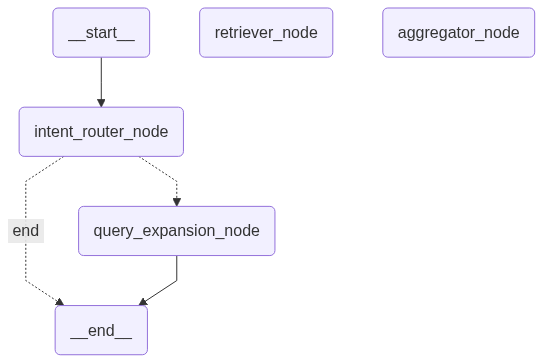

In [26]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
initial_state = {
    "initial_query": "Can I get a tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker?"
}

In [31]:
result = graph.invoke(initial_state)

In [32]:
result

{'expanded_query': ["Kid's tablet",
  'Adult watch',
  'Laptop for wife',
  'Waterproof speaker'],
 'retrieved_context': ['- ID: B0C4KCQB19, rating: 3.7, description: 7inch Tablet for Kids Android 11 Tablets 3GB 32GB Parental Control Children Learning Toddler Tablet Shockproof Kickstand Case, GMS Certified, Google Tableta YouTube Netflix (Pink) ★[Best Kids-Friendly Compansion ] -With parental control mode, you can create and customize profiles for kids’accounts, hand-pick content for your kids, control screen time and ensure they are browsing safe websites. These security settings can be adjusted as kids grow with content tailored to their age. ★[A Full-feature Tablet for Kids] - This kids edition tablet has built-in a high-performance quad-core processor with stable Android 11 smooth System OS, 1024x600 IPS HD display, Wifi, Bluetooth, dual camera with flash, touch screen, 3GB RAM and 32GB ROM. You can expand the storage to 256GB of SD cards for storing photos, music, videos. A more s

In [33]:
print(result["answer"])

Here are suitable options from the available products for each of your needs:

- **Tablet for your kid:**
  - **B0C4KCQB19** — 7-inch Kids Tablet
  - Android 11 with **3GB RAM / 32GB ROM**
  - **Parental control mode** to manage profiles, screen time, and safe browsing
  - **1024x600 IPS HD display**, Wi‑Fi, Bluetooth, dual camera with flash
  - **Expandable storage up to 256GB** via SD card
  - **3000mAh battery**
  - Includes a **kid-proof shockproof case** with a built-in kickstand
  - Google certified and supports apps like **YouTube** and **Netflix**

- **Watch for you:**
  - **B0C7QXCV62** — Smart Watch for Men Women with Alexa Built-in
  - **1.95" HD screen**
  - Supports **answering/making calls** and message notifications
  - Tracks **heart rate, blood oxygen, stress, sleep**, and activity
  - **100+ sports modes**
  - **IP68 waterproof**
  - Battery life up to **7–10 days of daily use** and up to **30 days standby**
  - Compatible with **Android and iOS**

- **Laptop for your

In [34]:
initial_state = {
    "initial_query": "How many times should I be walking my dog per day?"
}

In [35]:
result = graph.invoke(initial_state)

In [36]:
result

{'retrieved_context': [],
 'initial_query': 'How many times should I be walking my dog per day?',
 'answer': 'This question is about pet care advice, not products, inventory, or purchasing.',
 'question_relevant': False}